<a href="https://colab.research.google.com/github/Lasal0425/ML_Models/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the dependancies


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

In [6]:
house_price_dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML Projects/House Price Prediction/HousingData.csv')

In [7]:
house_price_dataset.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [8]:
#Number of rows and columns
house_price_dataset.shape

(506, 14)

In [9]:
#getting statistcal data of the dataset
house_price_dataset.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [10]:
# Check for missng values
house_price_dataset.isnull().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


Replace the missing values with median value

In [11]:
cols_to_impute = ['CRIM', 'ZN', 'INDUS', 'AGE', 'LSTAT']
house_price_dataset[cols_to_impute] = house_price_dataset[cols_to_impute].fillna(house_price_dataset[cols_to_impute].median())

In [12]:
house_price_dataset['CHAS'] = house_price_dataset['CHAS'].fillna(house_price_dataset['CHAS'].mode()[0])

In [13]:
house_price_dataset.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [14]:
house_price_dataset.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.479140,10.768775,11.028893,0.067194,0.554695,6.284634,68.845850,3.795043,9.549407,408.237154,18.455534,356.674032,12.664625,22.532806
std,8.570832,23.025124,6.704679,0.250605,0.115878,0.702617,27.486962,2.105710,8.707259,168.537116,2.164946,91.294864,7.017219,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.083235,0.000000,5.190000,0.000000,0.449000,5.885500,45.925000,2.100175,4.000000,279.000000,17.400000,375.377500,7.230000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,2.808720,0.000000,18.100000,0.000000,0.624000,6.623500,93.575000,5.188425,24.000000,666.000000,20.200000,396.225000,16.570000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


Understanding the correlation between various features in the dataset

In [15]:
correlation = house_price_dataset.corr()

<Axes: >

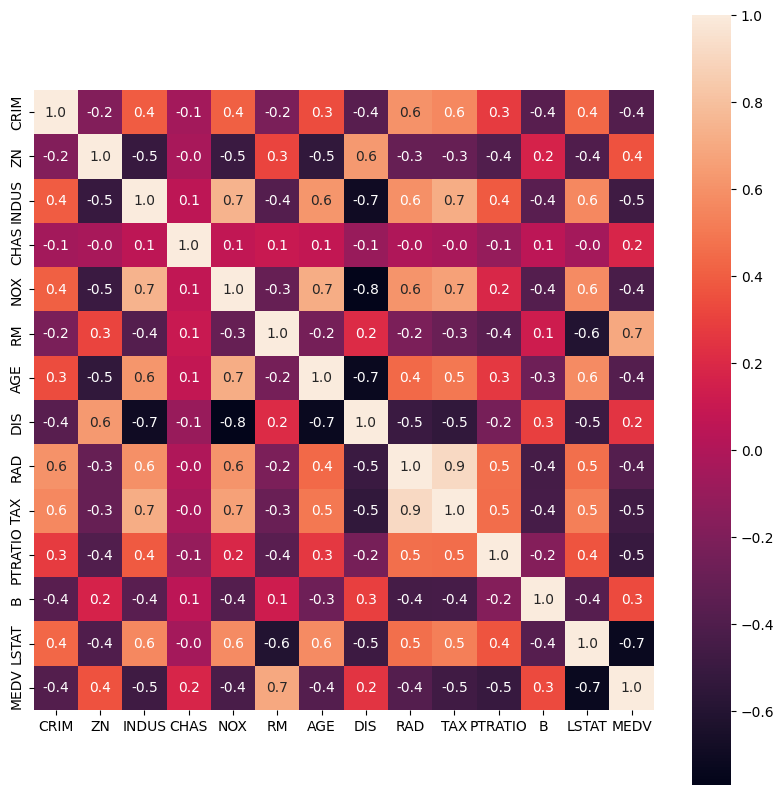

In [16]:
# Constructing a heat map to undertand the correlation
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True)

Splitting the data and target


In [17]:
X = house_price_dataset.drop(columns=['MEDV'], axis=1)
Y = house_price_dataset['MEDV']

In [18]:
print(X)
print(Y)

        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  \
0    0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296   
1    0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242   
2    0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242   
3    0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222   
4    0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...  ...   
501  0.06263   0.0  11.93   0.0  0.573  6.593  69.1  2.4786    1  273   
502  0.04527   0.0  11.93   0.0  0.573  6.120  76.7  2.2875    1  273   
503  0.06076   0.0  11.93   0.0  0.573  6.976  91.0  2.1675    1  273   
504  0.10959   0.0  11.93   0.0  0.573  6.794  89.3  2.3889    1  273   
505  0.04741   0.0  11.93   0.0  0.573  6.030  76.8  2.5050    1  273   

     PTRATIO       B  LSTAT  
0       15.3  396.90   4.98  
1       17.8  396.90   9.14  
2       17.8  392.83   4.03  
3  

Splitting the data into training data and test data

In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [20]:
print(X.shape, X_train.shape, X_test.shape)

(506, 13) (404, 13) (102, 13)


Model Training

In [21]:
# loading the model
model = XGBRegressor()

In [22]:
# training the model with X_train
model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Evaluation

Prediction on training data

In [23]:
# accuracy for prediction on training data
training_data_prediction = model.predict(X_train)

In [24]:
print(training_data_prediction)

[23.106466  21.003958  20.101652  34.692577  13.896075  13.496773
 21.999298  15.197643  10.900634  22.696138  13.804111   5.594369
 29.796469  49.998966  34.899506  20.598284  23.382044  19.211777
 32.697315  19.599575  26.992937   8.405825  46.000767  21.692762
 27.083265  19.37228   19.286379  24.805056  22.605177  31.702682
 18.504084   8.701991  17.40847   23.701145  13.29415   10.514749
 12.707923  24.99681   19.700748  14.908483  24.192677  24.999523
 14.899642  17.002169  15.597424  12.707141  24.50357   15.003123
 49.999218  17.530506  21.211622  32.00973   15.606417  22.900713
 19.289425  18.693918  23.301413  37.197025  30.102762  33.104923
 20.979067  49.98572   13.402516   4.9968534 16.499813   8.394927
 28.677383  19.515425  20.604267  45.401505  39.807293  33.407944
 19.809435  33.399784  25.287796  50.002625  12.517135  17.427906
 18.6065    22.593763  50.003666  23.80418   23.314482  23.096462
 41.702965  16.100708  31.604473  36.0957     7.00758   20.403147
 20.001593

In [25]:
# R squared error
error_score = metrics.r2_score(Y_train, training_data_prediction)
print("R squared error : ", error_score)

R squared error :  0.9999982455549916


In [26]:
# mean squared error
error_score = metrics.mean_squared_error(Y_train, training_data_prediction)
print("Mean squared error : ", error_score)

Mean squared error :  0.00014837323925751846


Visualizing the actual prices and predicted prices

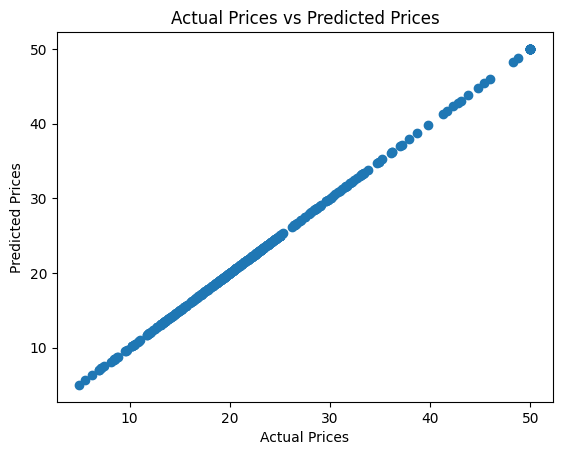

In [31]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

Prediction on test data


In [28]:
# accuracy for prediction on test data
test_data_prediction = model.predict(X_test)
print(test_data_prediction)

[21.17889   20.254873  28.376375  30.720716   9.486799  14.4737015
 29.087076  30.022127  15.766564  20.077057  27.364899  25.015472
 19.23332   22.111008  23.234797  21.563784  17.032082   8.421756
  9.464934  14.221999  22.358503  19.928114  35.81559   18.611023
 13.277548  18.795244  40.649605  32.53839   33.572556  19.150791
 16.849958  19.86562   30.194767  23.285578   8.768663  19.20806
  8.159395  21.284067  21.923777  21.005548  27.243425  12.337354
 28.668713   7.571294  20.548647  13.987994  34.106987  15.641323
 30.41471   14.349665  31.812439  27.789373   6.9677687 33.76142
 21.602486  19.692907  19.555054  20.81308   15.106344  21.299877
 21.233515  22.48057   17.46718   29.794916  33.682053  25.909327
 48.532032  30.8626     8.894279  23.861025  15.880085   8.424783
 13.909606  19.037249  27.232157  23.637596  21.540052  22.192776
 19.581406  23.737263  33.331898  17.43085   19.906057  30.50895
 35.631115  35.08701   17.55909   25.086237  30.241907  17.608152
 20.345093  

In [29]:
# R squared error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared error : ", error_score)

R squared error :  0.876530936868114


In [30]:
# mean squared error
error_score = metrics.mean_squared_error(Y_test, test_data_prediction)
print("Mean squared error : ", error_score)

Mean squared error :  10.329382540318027
